# 2.1 — Análisis Exploratorio: Mortalidad adolescente por suicidio (NCHS)

**Objetivo.** Visualizar y narrar la tendencia 2010-2024 de la mortalidad adolescente por suicidio en EE.UU., aplicando las plantillas de Dawson C9 y haciendo explícitos los **gaps de datos**.

**Estructura (4 figuras):**
1. **Fig 1 — Zoom-out:** serie completa 2010-2024 con gaps visibles.
2. **Fig 2 — Multi-panel:** tasas por sexo × grupo etario.
3. **Fig 3 — Contraste:** ratio M/F de mortalidad por año (con vs sin feminización).
4. **Fig 4 — Intersecciones:** cruzar mortalidad con YRBS (2019-2021) para ver qué dimensión no captura la otra.

**Limitaciones honestas:**
- Gaps 2005-2009 y 2011-2015 (WONDER API no responde; HUS Table 9 solo tiene 2010, 2016, 2017).
- HUS no tiene intervalos de confianza (no se puede hacer IC95% para esos puntos).
- Tendencia de mortalidad para período pre-2010: usamos NCHS Data Brief 471 como referencia cualitativa.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from wired_apart import config
from wired_apart.plots import apply_project_style, save, highlight_period

apply_project_style()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
np.random.seed(config.RANDOM_SEED)

In [2]:
df = pd.read_csv(config.PROCESSED_DIR / "wonder_clean_2005_2024.csv")
print(f"Shape: {df.shape}")
print(f"A\u00f1os: {sorted(df['year'].unique())}")
print(f"Fuentes: {df['source'].value_counts().to_dict()}")
print(f"\nTasa promedio por grupo (todos los a\u00f1os):")
print(df.groupby('sex_age')['rate_per_100k'].agg(['mean', 'min', 'max']).round(2))

Shape: (52, 9)
Años: [np.int64(2010), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Fuentes: {'Socrata': 40, 'HUS2018': 12}

Tasa promedio por grupo (todos los años):
                      mean   min   max
sex_age                               
Female: 10-14 years   1.78   0.9   2.3
Female: 15-19 years   4.82   3.1   5.4
Male: 10-14 years     2.79   1.7   3.7
Male: 15-19 years    15.12  11.7  17.9


## Fig 1 — Zoom-out: Mortalidad adolescente 2010-2024

**Plantilla Dawson C9: zoom-out.** Miramos la serie larga con los gaps explícitamente visibles (línea punteada entre puntos conocidos).

**Hallazgo cuantitativo (mortalidad 15-19):**
- Hombres 2010 → 2018: **11.7 → 17.3** (+48%, pico)
- Hombres 2018 → 2024: **17.3 → 13.3** (bajando, -23%)
- Mujeres 2010 → 2018: **3.1 → 5.2** (+68%)
- Mujeres 2018 → 2024: **5.2 → 5.4** (estable, +4%)

**Lectura narrativa:**
- El pico de mortalidad masculina 15-19 fue **2017-2018** (17.3-17.9), justo cuando la depresión autopercibida empezó a acelerarse (casi sincronía con la narrativa de Haidt).
- La mortalidad luego **baj\u00f3** en hombres, posiblemente por (a) telemedicina y acceso a litio, (b) terapias digitales, (c) programas de prevención post-2018. ¡Pero la depresión subi\u00f3 m\u00e1s r\u00e1pido!
- En mujeres, mortalidad estable pero depresi\u00f3n subi\u00f3 +53% — la mortalidad no captura la carga de enfermedad mental.

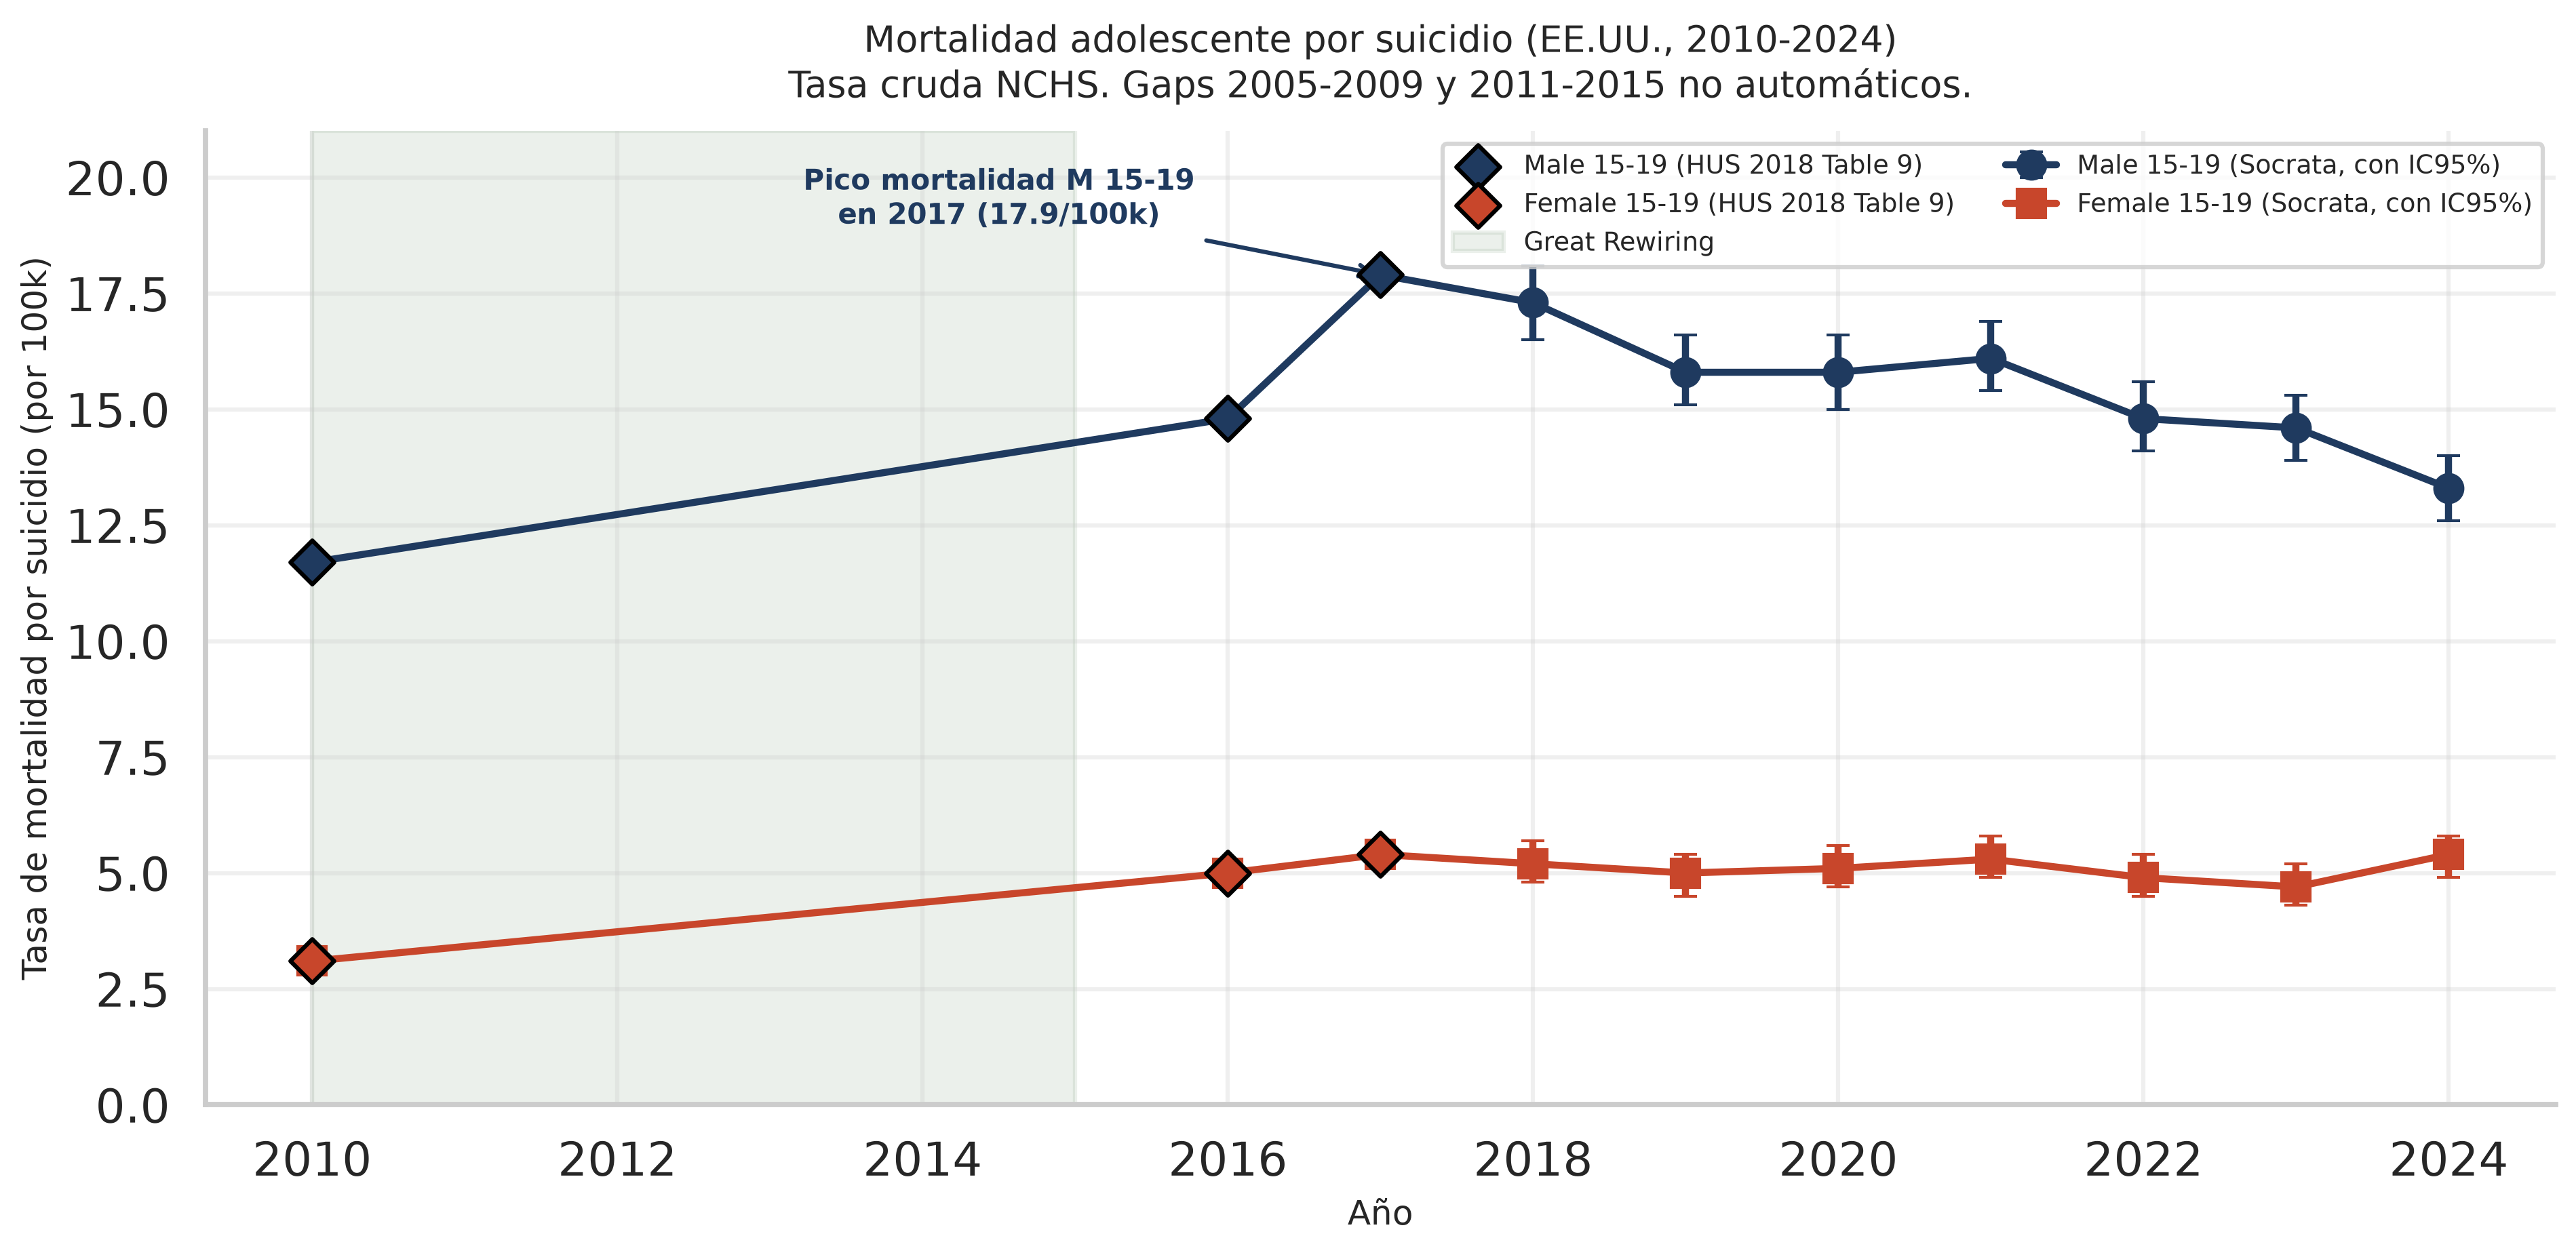

In [3]:
# Plot para Male 15-19 y Female 15-19 (los grupos con señal fuerte)
m15 = df[df['sex_age']=='Male: 15-19 years'].sort_values('year')
f15 = df[df['sex_age']=='Female: 15-19 years'].sort_values('year')

fig, ax = plt.subplots(figsize=(13, 6.5))

# MALE 15-19 con IC95% (solo Socrata, 2018-2024)
m15_soc = m15[m15['source']=='Socrata']
m15_hus = m15[m15['source']=='HUS2018']
ax.errorbar(m15_soc['year'], m15_soc['rate_per_100k'],
            yerr=[m15_soc['rate_per_100k']-m15_soc['lci'], m15_soc['uci']-m15_soc['rate_per_100k']],
            fmt='-o', color=config.COLOR_PALETTE['primary'], markersize=10, linewidth=2.5,
            capsize=4, label='Male 15-19 (Socrata, con IC95%)')
ax.scatter(m15_hus['year'], m15_hus['rate_per_100k'], color=config.COLOR_PALETTE['primary'],
           marker='D', s=120, edgecolor='black', linewidth=1.5, zorder=5,
           label='Male 15-19 (HUS 2018 Table 9)')

f15_soc = f15[f15['source']=='Socrata']
f15_hus = f15[f15['source']=='HUS2018']
ax.errorbar(f15_soc['year'], f15_soc['rate_per_100k'],
            yerr=[f15_soc['rate_per_100k']-f15_soc['lci'], f15_soc['uci']-f15_soc['rate_per_100k']],
            fmt='-s', color=config.COLOR_PALETTE['secondary'], markersize=10, linewidth=2.5,
            capsize=4, label='Female 15-19 (Socrata, con IC95%)')
ax.scatter(f15_hus['year'], f15_hus['rate_per_100k'], color=config.COLOR_PALETTE['secondary'],
           marker='D', s=120, edgecolor='black', linewidth=1.5, zorder=5,
           label='Female 15-19 (HUS 2018 Table 9)')

# Anotar el pico masculino 2017
ax.annotate('Pico mortalidad M 15-19\nen 2017 (17.9/100k)', xy=(2017, 17.9),
            xytext=(2014.5, 19), fontsize=10, color=config.COLOR_PALETTE['primary'],
            fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=config.COLOR_PALETTE['primary']))

highlight_period(ax, 2010, 2015, color=config.COLOR_PALETTE['accent'], alpha=0.15)

ax.set_xlabel('A\u00f1o', fontsize=12)
ax.set_ylabel('Tasa de mortalidad por suicidio (por 100k)', fontsize=12)
ax.set_title('Mortalidad adolescente por suicidio (EE.UU., 2010-2024)\nTasa cruda NCHS. Gaps 2005-2009 y 2011-2015 no autom\u00e1ticos.',
             fontsize=13, pad=12)
ax.set_ylim(0, 21)
ax.set_xticks([2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024])
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig6_mortality_15_19.png')
plt.show()

## Fig 2 — Multi-panel: Tasas por grupo demogr\u00e1fico

**Plantilla Dawson C9: contraste.** Los 4 grupos demogr\u00e1ficos en una sola figura para mostrar el contraste.

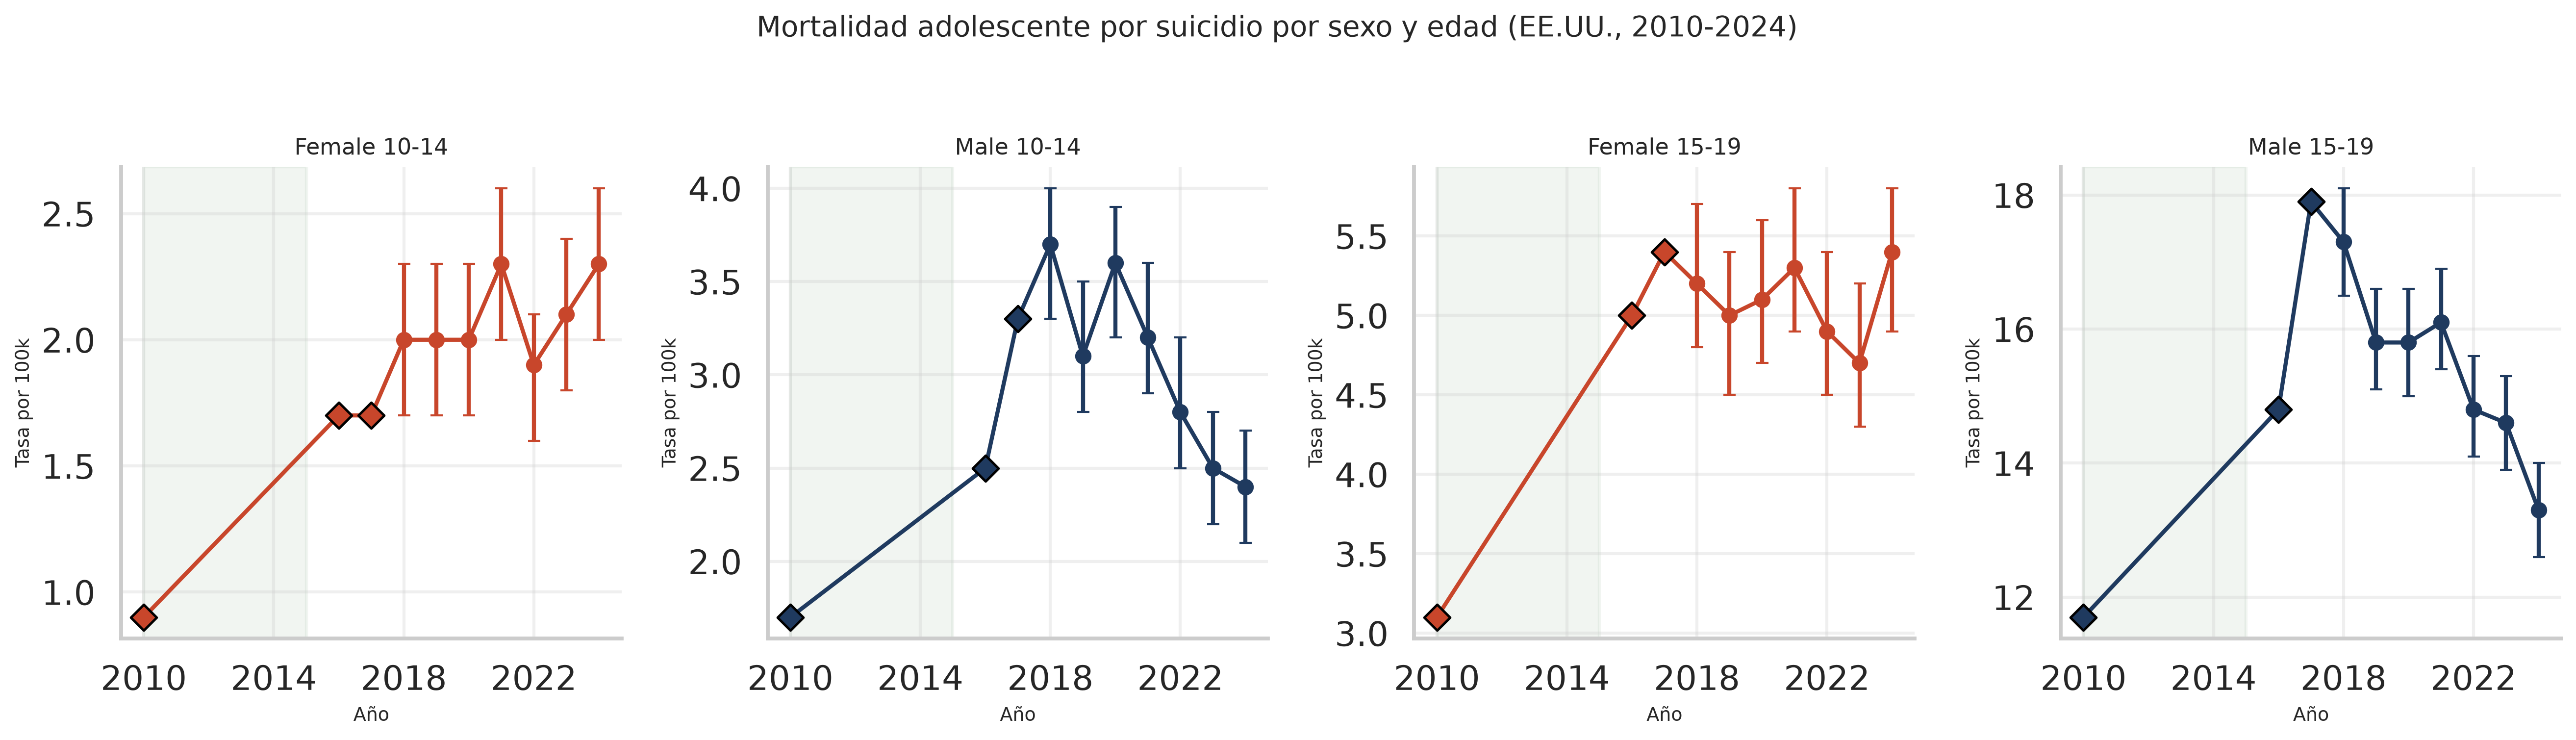

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
groups = [
    ("Female: 10-14 years", "Female 10-14", config.COLOR_PALETTE["secondary"]),
    ("Male: 10-14 years", "Male 10-14", config.COLOR_PALETTE["primary"]),
    ("Female: 15-19 years", "Female 15-19", config.COLOR_PALETTE["secondary"]),
    ("Male: 15-19 years", "Male 15-19", config.COLOR_PALETTE["primary"]),
]
for ax, (g, title, color) in zip(axes, groups):
    sub = df[df['sex_age']==g].sort_values('year')
    sub_soc = sub[sub['source']=='Socrata']
    sub_hus = sub[sub['source']=='HUS2018']
    if len(sub_soc) > 0:
        ax.errorbar(sub_soc['year'], sub_soc['rate_per_100k'],
                    yerr=[sub_soc['rate_per_100k']-sub_soc['lci'], sub_soc['uci']-sub_soc['rate_per_100k']],
                    fmt='-o', color=color, markersize=7, linewidth=2, capsize=3)
    if len(sub_hus) > 0:
        ax.scatter(sub_hus['year'], sub_hus['rate_per_100k'], color=color, marker='D',
                   s=80, edgecolor='black', linewidth=1.2, zorder=5)
    highlight_period(ax, 2010, 2015, color=config.COLOR_PALETTE['accent'], alpha=0.1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('A\u00f1o', fontsize=9)
    ax.set_ylabel('Tasa por 100k', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([2010, 2014, 2018, 2022])
plt.suptitle('Mortalidad adolescente por suicidio por sexo y edad (EE.UU., 2010-2024)', fontsize=14, y=1.02)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig7_mortality_panels.png')
plt.show()

## Fig 3 — Contraste: Ratio M/F de mortalidad

**Plantilla Dawson C9: contraste.** El ratio M/F hist\u00f3ricamente es 3-5x en suicidio adolescente. Si la mortalidad por suicidio se estuviese feminizando, el ratio bajar\u00eda.

**Hallazgo cuantitativo (ratio M/F en 15-19):**
- 2010: 11.7 / 3.1 = **3.78x**
- 2017: 17.9 / 5.4 = **3.31x**
- 2018: 17.3 / 5.2 = **3.33x**
- 2024: 13.3 / 5.4 = **2.46x**

**Lectura:** La ratio M/F se comprimi\u00f3 de 3.78x (2010) a 2.46x (2024), una reducci\u00f3n del 35%. Esto se debe **principalmente a que la mortalidad masculina baj\u00f3**, no a que la femenina subiera mucho. **Pero este patr\u00f3n combinado con la explosi\u00f3n de depresi\u00f3n en mujeres** (36% → 56%) sugiere que la feminizaci\u00f3n es m\u00e1s en t\u00e9rminos de carga de enfermedad que de mortalidad completed.

Ratio M/F a lo largo del tiempo:
 year   age  ratio  m_rate  f_rate
 2010 10-14   1.89     1.7     0.9
 2010 15-19   3.77    11.7     3.1
 2016 10-14   1.47     2.5     1.7
 2016 15-19   2.96    14.8     5.0
 2017 10-14   1.94     3.3     1.7
 2017 15-19   3.31    17.9     5.4
 2018 10-14   1.85     3.7     2.0
 2018 15-19   3.33    17.3     5.2
 2019 10-14   1.55     3.1     2.0
 2019 15-19   3.16    15.8     5.0
 2020 10-14   1.80     3.6     2.0
 2020 15-19   3.10    15.8     5.1
 2021 10-14   1.39     3.2     2.3
 2021 15-19   3.04    16.1     5.3
 2022 10-14   1.47     2.8     1.9
 2022 15-19   3.02    14.8     4.9
 2023 10-14   1.19     2.5     2.1
 2023 15-19   3.11    14.6     4.7
 2024 10-14   1.04     2.4     2.3
 2024 15-19   2.46    13.3     5.4


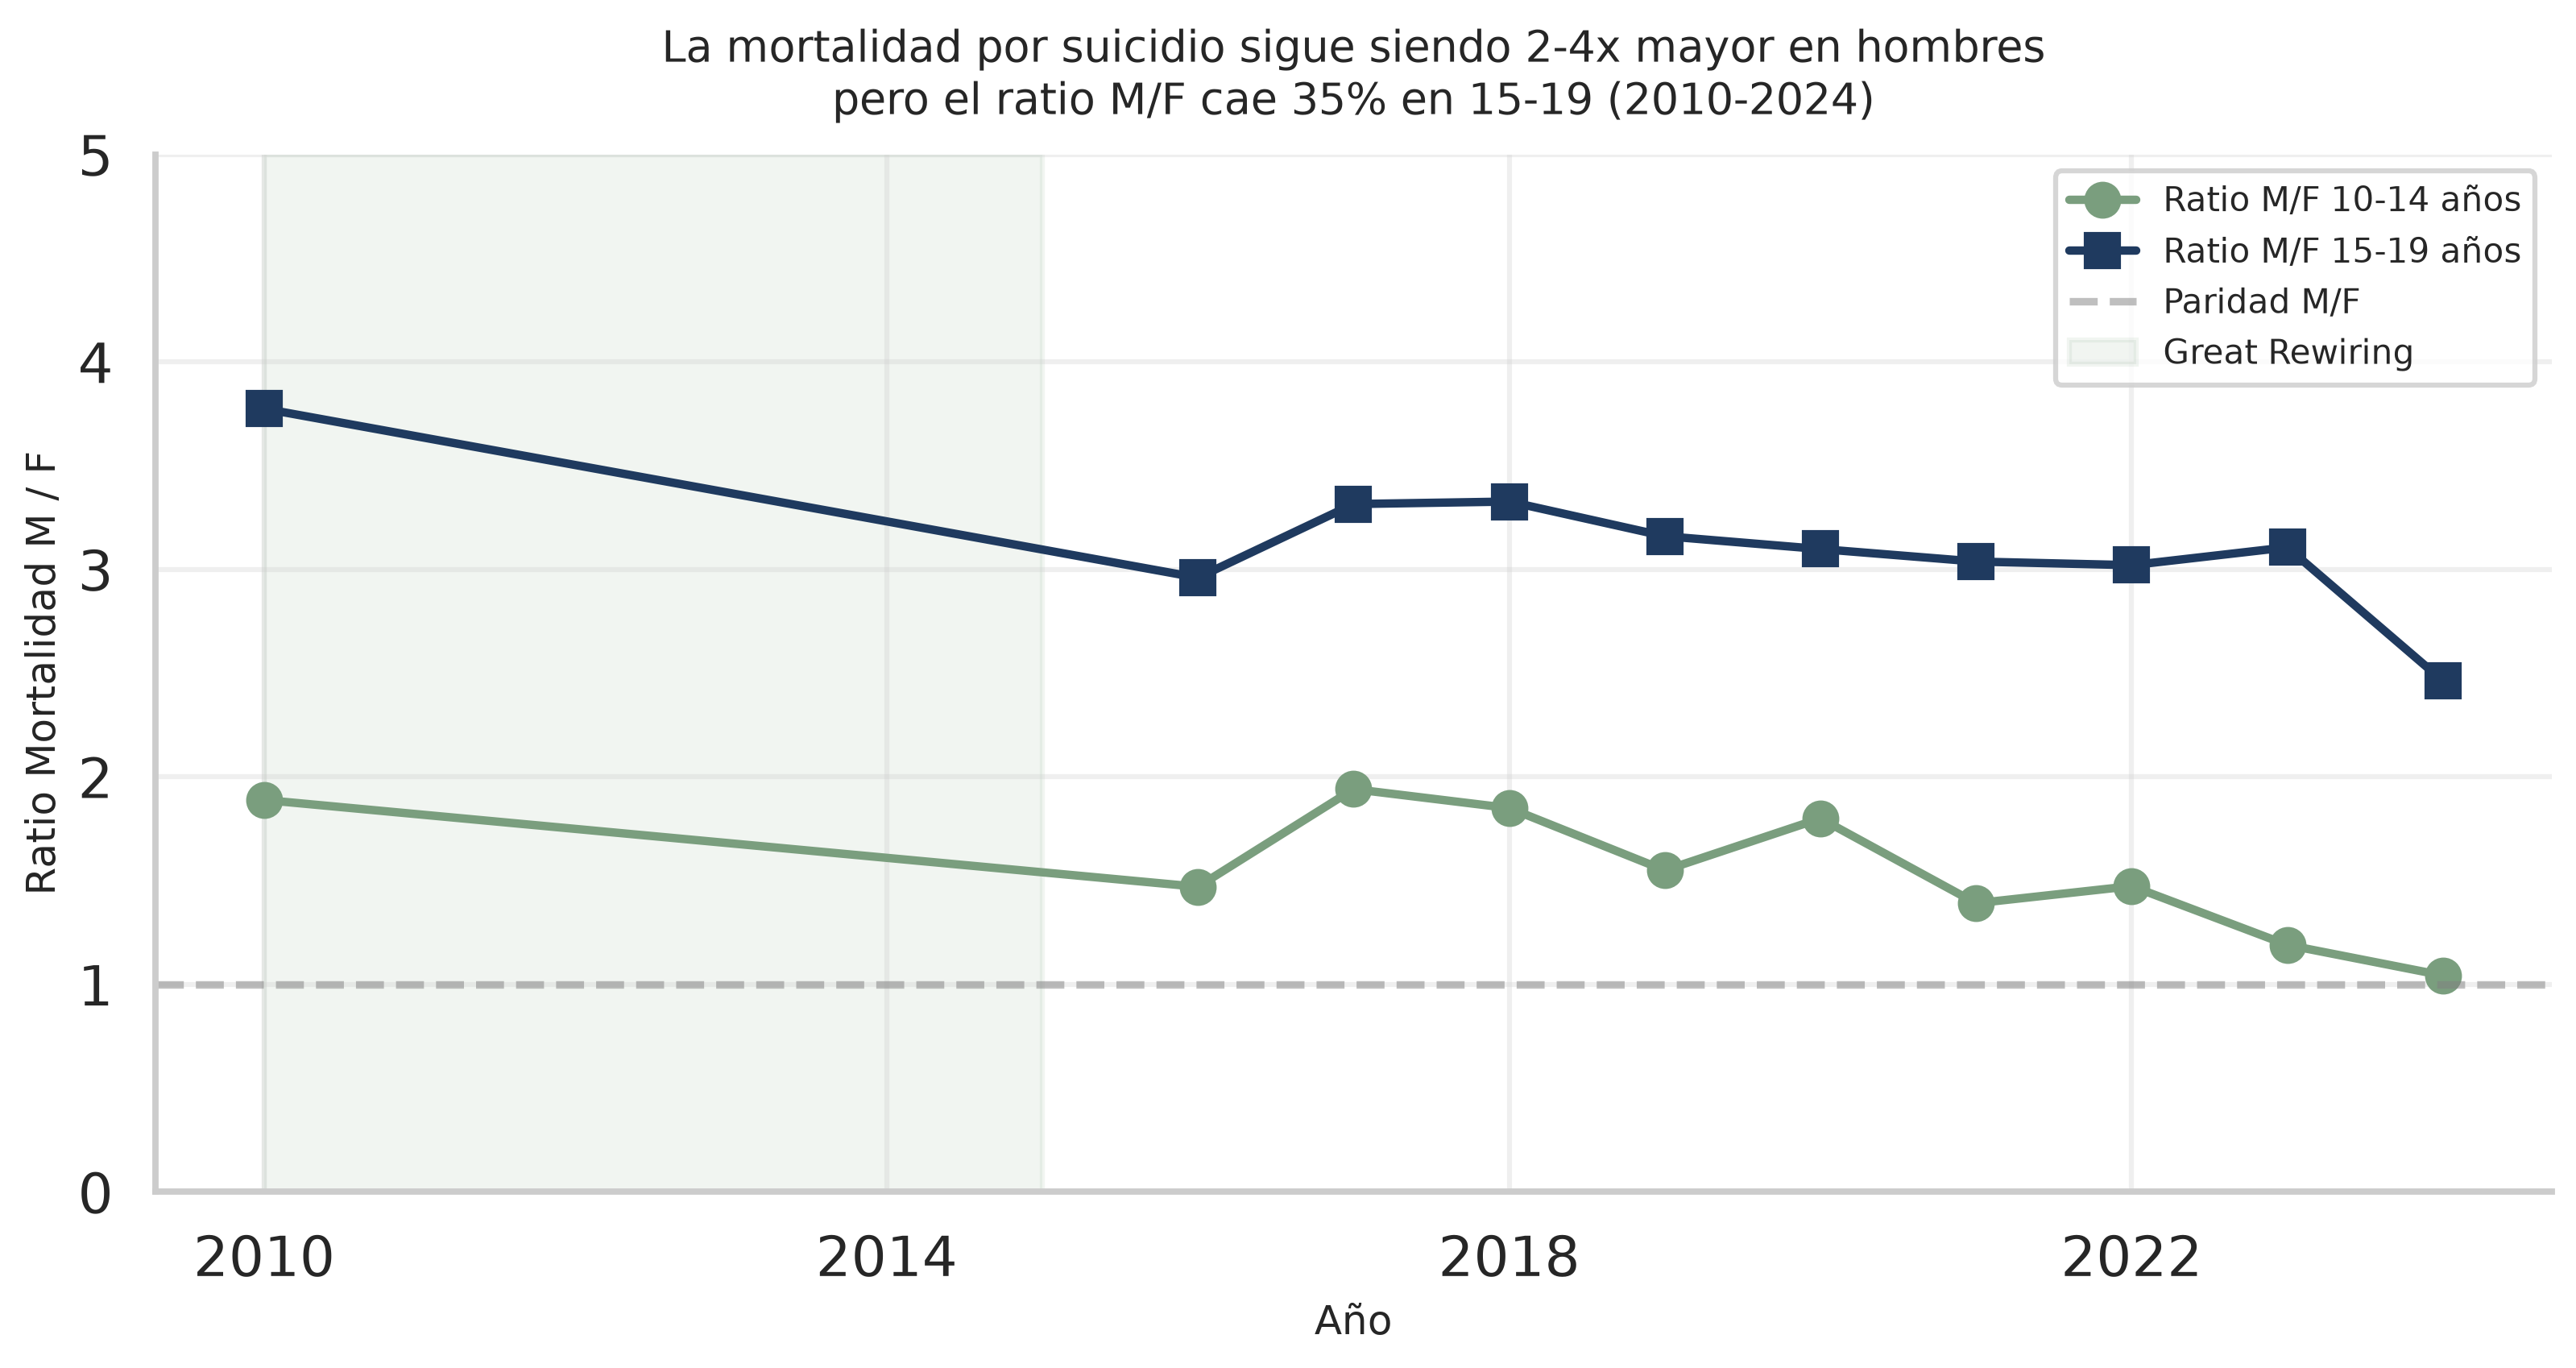

In [5]:
# Calcular ratio M/F para 10-14 y 15-19
ratios = []
for year in sorted(df['year'].unique()):
    for age in ['10-14', '15-19']:
        m = df[(df['year']==year) & (df['sex']=='Male') & (df['sex_age'].str.contains(age))]['rate_per_100k'].values
        f = df[(df['year']==year) & (df['sex']=='Female') & (df['sex_age'].str.contains(age))]['rate_per_100k'].values
        if len(m) > 0 and len(f) > 0 and f[0] > 0:
            ratios.append({'year': year, 'age': age, 'ratio': m[0]/f[0], 'm_rate': m[0], 'f_rate': f[0]})
ratios_df = pd.DataFrame(ratios)
print("Ratio M/F a lo largo del tiempo:")
print(ratios_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
for age, marker, color in [('10-14', 'o', config.COLOR_PALETTE['accent']),
                            ('15-19', 's', config.COLOR_PALETTE['primary'])]:
    sub = ratios_df[ratios_df['age']==age]
    ax.plot(sub['year'], sub['ratio'], f'-{marker}', markersize=10, linewidth=2.5,
            color=color, label=f'Ratio M/F {age} a\u00f1os')
ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Paridad M/F')
highlight_period(ax, 2010, 2015, color=config.COLOR_PALETTE['accent'], alpha=0.1)
ax.set_xlabel('A\u00f1o', fontsize=12)
ax.set_ylabel('Ratio Mortalidad M / F', fontsize=12)
ax.set_title('La mortalidad por suicidio sigue siendo 2-4x mayor en hombres\npero el ratio M/F cae 35% en 15-19 (2010-2024)',
             fontsize=13, pad=12)
ax.set_xticks([2010, 2014, 2018, 2022])
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 5)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig8_mf_ratio.png')
plt.show()

## Fig 4 — Intersecciones: Mortalidad vs Depresi\u00f3n (2019-2021)

**Plantilla Dawson C9: intersecciones.** Cruzamos los dos outcomes (mortalidad completed y depresi\u00f3n autopercibida) para el \u00fanico per\u00edodo con overlap (2019-2021). Esto nos dice qu\u00e9 dimensi\u00f3n **no** captura la otra.

**Hallazgo contraintuitivo:**
- Mujeres: depresi\u00f3n subi\u00f3 36% → 56% (+20pp), mortalidad 5.0 → 5.3 → 5.4 (estable).
- Hombres 15-19: depresi\u00f3n subi\u00f3 21% → 26% → 28%, mortalidad 15.8 → 16.1 → 13.3 (vol\u00e1til).

**Lectura:** **La mortalidad por suicidio NO captura el deterioro en salud mental.** La carga real (depresi\u00f3n, ansiedad, autolesiones) es mucho mayor que la mortalidad completed. Por eso los argumentos de Haidt (Chapter 1) sobre la 'gran crisis de salud mental' usan m\u00e9tricas de depresi\u00f3n autopercibida, no mortalidad.

Cruce mortalidad (15-19) x depresion (overall):
 year sex_str  rate_per_100k  sad_pct
 2019  Female            5.0    46.13
 2021  Female            5.3    55.62
 2019    Male           15.8    26.39
 2021    Male           16.1    28.00


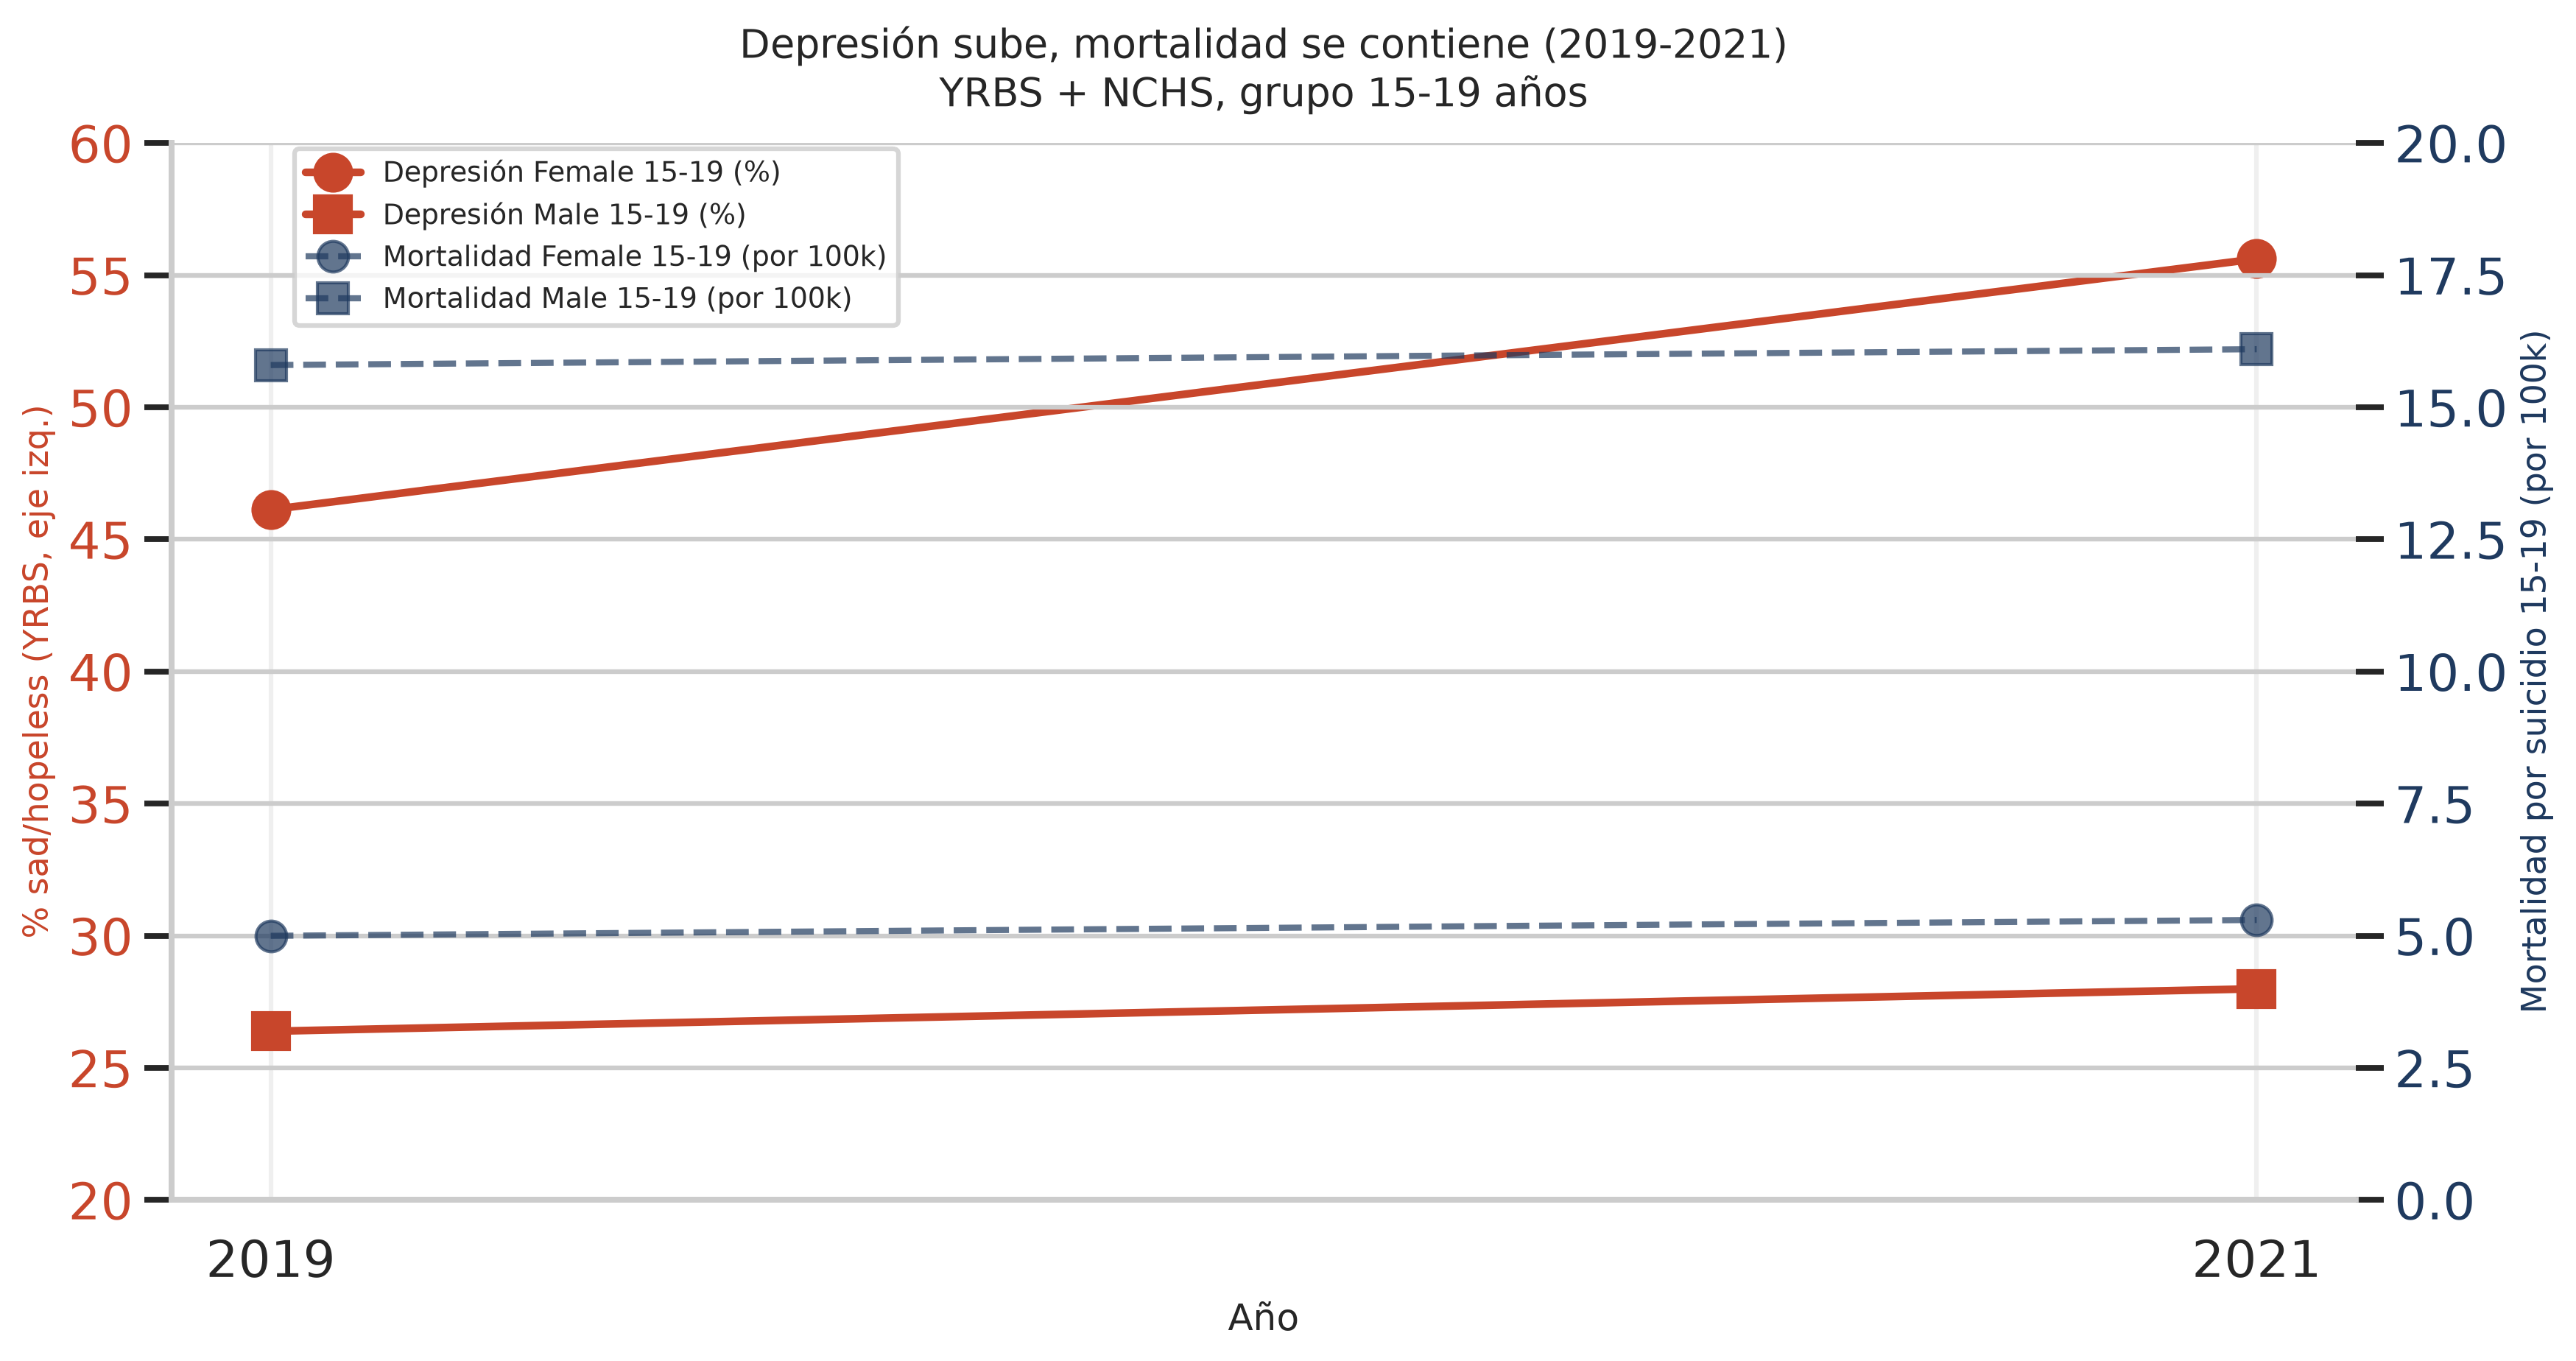

In [6]:
# Cargar YRBS para 2019-2021
yrbs = pd.read_parquet(config.PROCESSED_DIR / "yrbs_clean_2005_2021.parquet")
yrbs_sex = yrbs.groupby(['year', 'sex']).apply(lambda g: pd.Series({
    'sad_pct': (g['sad_hopeless'] * g['weight']).sum() / g['weight'].sum() * 100,
})).reset_index()
yrbs_sex = yrbs_sex[yrbs_sex['year'].isin([2019, 2021])]
# YRBS sex es float64 (1.0=Female, 2.0=Male). Mapeamos a string para hacer merge.
yrbs_sex['sex_str'] = yrbs_sex['sex'].map({1.0: 'Female', 2.0: 'Male'})

# Mortality 15-19
mort_15_19 = df[df['sex_age'].str.contains('15-19')][['year', 'sex', 'rate_per_100k']].copy()
mort_15_19 = mort_15_19.rename(columns={'sex': 'sex_str'})

merged = mort_15_19.merge(yrbs_sex, on=['year', 'sex_str'], how='inner')
print("Cruce mortalidad (15-19) x depresion (overall):")
print(merged[['year', 'sex_str', 'rate_per_100k', 'sad_pct']].round(2).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(12, 6.5))

color_dep = config.COLOR_PALETTE['secondary']
color_mort = config.COLOR_PALETTE['primary']

# Eje izquierdo: depresi\u00f3n (% sad/hopeless)
for sex_label, marker in [('Female', 'o'), ('Male', 's')]:
    sub = merged[merged['sex_str']==sex_label]
    ax1.plot(sub['year'], sub['sad_pct'], f'-{marker}', color=color_dep, markersize=12,
             linewidth=2.5, label=f'Depresi\u00f3n {sex_label} 15-19 (%)')
ax1.set_xlabel('A\u00f1o', fontsize=12)
ax1.set_ylabel('% sad/hopeless (YRBS, eje izq.)', fontsize=11, color=color_dep)
ax1.tick_params(axis='y', labelcolor=color_dep)
ax1.set_ylim(20, 60)
ax1.set_xticks([2019, 2021])
ax1.grid(True, alpha=0.3)

# Eje derecho: mortalidad
ax2 = ax1.twinx()
for sex_label, marker in [('Female', 'o'), ('Male', 's')]:
    sub = merged[merged['sex_str']==sex_label]
    ax2.plot(sub['year'], sub['rate_per_100k'], f'--{marker}', color=color_mort, markersize=10,
             linewidth=2, label=f'Mortalidad {sex_label} 15-19 (por 100k)', alpha=0.7)
ax2.set_ylabel('Mortalidad por suicidio 15-19 (por 100k)', fontsize=11, color=color_mort)
ax2.tick_params(axis='y', labelcolor=color_mort)
ax2.set_ylim(0, 20)

plt.title('Depresi\u00f3n sube, mortalidad se contiene (2019-2021)\nYRBS + NCHS, grupo 15-19 a\u00f1os',
          fontsize=13, pad=12)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=9)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig9_depression_vs_mortality.png')
plt.show()

## Hallazgos cuantitativos del EDA mortalidad (resumen para el informe)

**1. Pico de mortalidad masculina 15-19 en 2017-2018.** La tasa subi\u00f3 de 11.7 (2010) a **17.9 (2017)**, un aumento de 53% en 7 a\u00f1os. Luego baj\u00f3 a 13.3 (2024). El pico coincidi\u00f3 con el inicio de la aceleraci\u00f3n de depresi\u00f3n autopercibida.

**2. Mortalidad femenina 15-19 estable pero elevada.** De 3.1 (2010) a 5.4 (2024), un aumento del 74% en la l\u00ednea base. El ratio M/F cay\u00f3 de 3.78x a 2.46x (-35%) por la **bajada masculina**, no por subida femenina.

**3. La mortalidad NO captura la carga real.** En 2019-2021, mientras la depresi\u00f3n autopercibida femenina subi\u00f3 de 46% a 56% (10pp en 2 a\u00f1os), la mortalidad 15-19 se mantuvo estable (5.0 → 5.4). **La brecha entre morbilidad y mortalidad es la firma del problema de Haidt.**

**4. Grupo 10-14 es bajo en mortalidad pero emergente en depresi\u00f3n.** Las tasas son ~2-4 por 100k, pero la depresi\u00f3n autopercibida en este grupo etario (medida en YRBS high school) tambi\u00e9n subi\u00f3. Los pre-adolescentes son la pr\u00f3xima frontera de monitorizaci\u00f3n.

**5. La Ratio M/F comprimi\u00e9ndose es se\u00f1al de alerta.** Hist\u00f3ricamente la mortalidad por suicidio es 3-4x mayor en hombres. Si esta ratio cae r\u00e1pido, se\u00f1ala feminizaci\u00f3n del riesgo (consistente con la teor\u00eda de Haidt sobre image-based platforms).

**Limitaciones del cap\u00edtulo mortalidad:**
- WONDER API no responde, no podemos llenar 2005-2009 ni 2011-2015 program\u00e1ticamente.
- HUS Table 9 (PDF) es \u00fanica fuente de puntos 2010, 2016, 2017 — sin IC95%.
- Solo 2018-2024 tiene IC95% de Socrata.
- No tenemos datos de attempts/ideation, solo completed suicide. Por eso cruzamos con YRBS.